# ADD TO FIGURE 3 NOTEBOOK

In [1]:
import fitness_landscape as fl
from fitness_landscape.utils import fasta_to_prot20_sequences
from fitness_landscape.core.landscape import FitnessLandscape
from fitness_landscape.transforms.eigenmode import eigenmode_decomposition
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import pickle
import json
from tqdm import tqdm
import networkx as nx
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import spearmanr
from scipy.stats import norm
import matplotlib as mpl

/home/matthewspence/graph-ruggedness-de/.env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-21 09:43:37,169	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


### Solution space size and ruggedness

In [2]:
n_params = range(4,11)
seeds = range(10)
rows = []

for _, seed in tqdm(enumerate(seeds)):
    for n_value in n_params:
        
        # Iterate through K parameters
        for k_value in range(0, n_value):

            nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

            layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
            fitness = layer.to_scalar()
            
            # Parititon f_min as the mean fitness
            mean_fitness = float(fitness.mean())
            solution_mask = fitness > mean_fitness

            # Attach categorical layer for the solution set
            labels = np.where(solution_mask, "solution", "non_solution").tolist()
            nk.attach(
                name="solution_set",
                values=labels,
                dtype="categorical",
                categories=["non_solution", "solution"],
            )

            # Conductance of the solution set
            G = nk.graph
            node_order = list(G.nodes())
            solution_nodes = [node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol]
            phi = nx.algorithms.cuts.conductance(G, solution_nodes, weight="weight")
            
            # tmap on landscape
            layer = nk.view(f"nk_k={k_value}")
            tmap_res = fl.analysis.diffusion_scale.compute_ruggedness_diffusion_scale(nk, t_min=1e-10, t_max=1e2)
            tmap = float(tmap_res.get("t_map", np.nan))
            tmap_upper_ci = float(tmap_res.get("t_upper_confidence_interval", np.nan))
            tmap_lower_ci = float(tmap_res.get("t_lower_confidence_interval", np.nan))

            res = {
                "seed": seed,
                "N" : n_value,
                "K" : k_value,
                "conductance" : phi,
                "tmap" : tmap,
                "tmap_lower_ci" : tmap_lower_ci,
                "tmap_upper_ci" : tmap_upper_ci,
            }

            rows.append(res)

df = pd.DataFrame(rows)

10it [05:18, 31.86s/it]


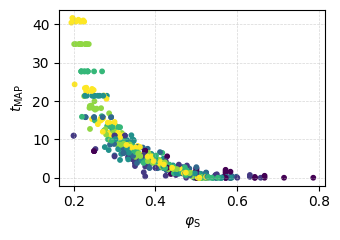

In [4]:
plt.figure(figsize=(3.5, 2.5))

plt.scatter(df['conductance'], df['tmap'], c=df['N'], s=10, alpha=1)
plt.ylabel(r"$t_{\mathrm{MAP}}$")
plt.xlabel(r"$φ_{\mathrm{S}}$")
plt.tight_layout()
plt.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.5)
plt.savefig('../figures/figure_3/conductance_S_vs_tmap.pdf')
plt.show()

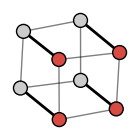

In [63]:
n_value = 3
k_value = 0
seed = 4

nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
fitness = layer.to_scalar()

# Parititon f_min as the mean fitness
mean_fitness = float(fitness.mean())
solution_mask = fitness > mean_fitness

# Attach categorical layer for the solution set
labels = np.where(solution_mask, "solution", "non_solution").tolist()
nk.attach(
    name="solution_set",
    values=labels,
    dtype="categorical",
    categories=["non_solution", "solution"],
)
nk.view("solution_set")


G = nk.graph
node_order = list(G.nodes())

# Build node -> solution label map
solution_nodes = set(node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol)

node_class = {
    node: ("solution" if node in solution_nodes else "non_solution")
    for node in node_order
}

# Split edges into boundary vs interior
boundary_edges = []
interior_edges = []

for u, v in G.edges():
    if node_class[u] != node_class[v]:
        boundary_edges.append((u, v))
    else:
        interior_edges.append((u, v))

# Layout (spring is fine for small NK graphs)
pos = nx.spring_layout(G, seed=1)

# Node colors
node_colors = [
    "#d84b43" if node in solution_nodes else "#cccccc"
    for node in G.nodes()
]

plt.figure(figsize=(1.5, 1.5))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=100,
    edgecolors="black"
)

# Draw interior edges (thin)
nx.draw_networkx_edges(
    G, pos,
    edgelist=interior_edges,
    width=1.,
    alpha=0.5,
    edge_color="black"
)

# Draw boundary edges (bold)
nx.draw_networkx_edges(
    G, pos,
    edgelist=boundary_edges,
    width=2.0,
    alpha=1.0,
    edge_color="black"
)

plt.axis("off")
plt.tight_layout()
plt.savefig('../figures/figure_3/nk_k=0_epsilonS.pdf')
plt.show()

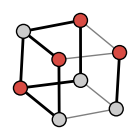

In [62]:
n_value = 3
k_value = 2
seed = 4

nk = fl.models.create_nk_binary_landscape(N=n_value, K=k_value, seed=seed)

layer = nk.view(f"nk_k={k_value}")  # active by default, but explicit is safe
fitness = layer.to_scalar()

# Parititon f_min as the mean fitness
mean_fitness = float(fitness.mean())
solution_mask = fitness > mean_fitness

# Attach categorical layer for the solution set
labels = np.where(solution_mask, "solution", "non_solution").tolist()
nk.attach(
    name="solution_set",
    values=labels,
    dtype="categorical",
    categories=["non_solution", "solution"],
)
nk.view("solution_set")


G = nk.graph
node_order = list(G.nodes())

# Build node -> solution label map
solution_nodes = set(node_order[i] for i, is_sol in enumerate(solution_mask) if is_sol)

node_class = {
    node: ("solution" if node in solution_nodes else "non_solution")
    for node in node_order
}

# Split edges into boundary vs interior
boundary_edges = []
interior_edges = []

for u, v in G.edges():
    if node_class[u] != node_class[v]:
        boundary_edges.append((u, v))
    else:
        interior_edges.append((u, v))

# Layout (spring is fine for small NK graphs)
pos = nx.spring_layout(G, seed=1)

# Node colors
node_colors = [
    "#d84b43" if node in solution_nodes else "#cccccc"
    for node in G.nodes()
]

plt.figure(figsize=(1.5, 1.5))

# Draw nodes
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=100,
    edgecolors="black"
)

# Draw interior edges (thin)
nx.draw_networkx_edges(
    G, pos,
    edgelist=interior_edges,
    width=1.,
    alpha=0.5,
    edge_color="black"
)

# Draw boundary edges (bold)
nx.draw_networkx_edges(
    G, pos,
    edgelist=boundary_edges,
    width=2.0,
    alpha=1.0,
    edge_color="black"
)

plt.axis("off")
plt.tight_layout()
plt.savefig('../figures/figure_3/nk_k=2_epsilonS.pdf')
plt.show()